# Olist E-Commerce Data Analysis

## Overview
This project analyses 100,000+ orders from Olist, Brazil's largest e-commerce
platform, covering 2016-2018. The goal is to uncover key business insights
around revenue growth, regional performance, and delivery operations.

## Business Questions
1. How has order volume and revenue grown over time?
2. Which states generate the most revenue and orders?
3. What is the average delivery time and how many orders are delayed?

## Dataset
- Source: Kaggle — Brazilian E-Commerce Public Dataset by Olist
- Period: September 2016 to August 2018
- Size: 100k+ orders across 9 tables

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Data Loading

The dataset consists of 9 CSV files. We load all of them and do a quick
inspection to understand the structure of each table.

In [3]:
!unzip archive.zip

orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')
item = pd.read_csv('olist_order_items_dataset.csv')

Archive:  archive.zip
  inflating: olist_customers_dataset.csv  
  inflating: olist_geolocation_dataset.csv  
  inflating: olist_order_items_dataset.csv  
  inflating: olist_order_payments_dataset.csv  
  inflating: olist_order_reviews_dataset.csv  
  inflating: olist_orders_dataset.csv  
  inflating: olist_products_dataset.csv  
  inflating: olist_sellers_dataset.csv  
  inflating: product_category_name_translation.csv  


## 2. Data Cleaning

Before analysis, we inspect each table for missing values, duplicates,
and incorrect data types, then fix the issues found.

**Issues found:**
- orders: 5 date columns stored as strings → converted to datetime
- products: 610 rows with missing values → dropped
- reviews: comment columns mostly empty → ignored for analysis
- geolocation: 261k duplicates → ignored (not used in analysis)

In [4]:
products = products.dropna(subset=['product_category_name','product_name_lenght','product_description_lenght','product_photos_qty'])
products = products.dropna(subset=['product_weight_g','product_length_cm','product_height_cm','product_width_cm'])

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

item['shipping_limit_date'] = pd.to_datetime(item['shipping_limit_date'])

print('Cleaning done!')
print(f'Products after cleaning: {products.shape}')

Cleaning done!
Products after cleaning: (32340, 9)


## 3. Analysis



### Q1. How has order volume and revenue grown over time?

We merge orders and payments tables to analyse monthly trends in
order count and revenue from 2016 to 2018.

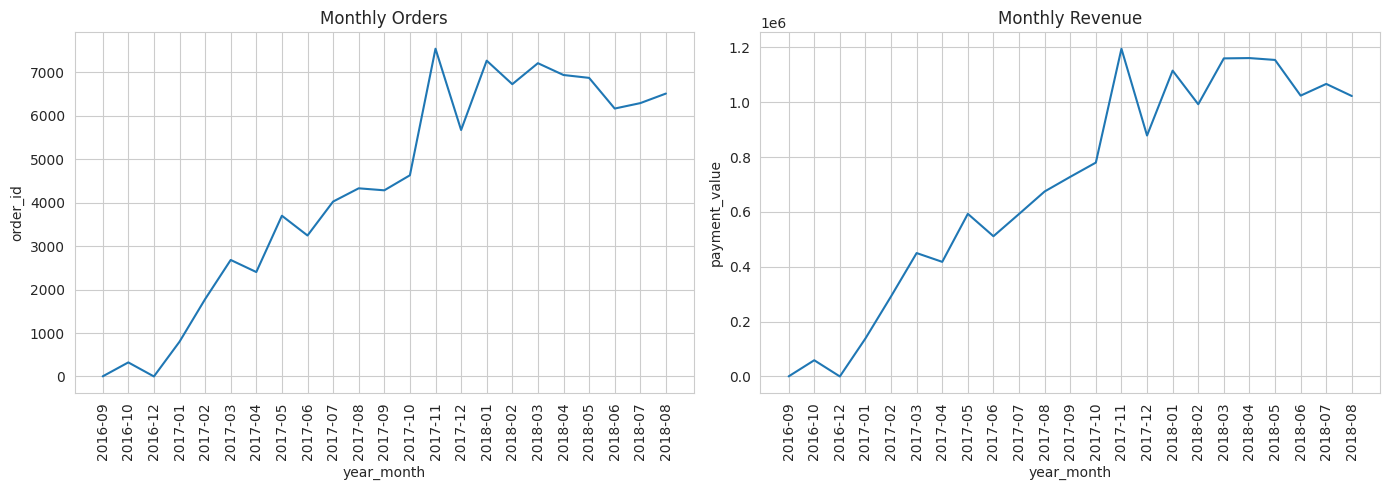

In [5]:
# merge orders and payments
orders_payment = pd.merge(orders, payments, on='order_id')

#extracting month and year
orders_payment['order_year'] = orders_payment['order_purchase_timestamp'].dt.year
orders_payment['order_month'] = orders_payment['order_purchase_timestamp'].dt.month

# group month and year
monthly = orders_payment.groupby(['order_year','order_month']).agg({'order_id':'nunique' , 'payment_value':'sum'}).reset_index()

# create year_month column
monthly['year_month'] = monthly['order_year'].astype(str) + '-' + monthly['order_month'].astype(str).str.zfill(2)

#removing incomplete months
monthly_clean = monthly[~monthly['year_month'].isin(['2018-09', '2018-10'])]

# Q1 visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=monthly_clean, x="year_month", y="order_id", ax=axes[0])
axes[0].set_title('Monthly Orders')
axes[0].tick_params(axis='x', rotation=90)

sns.lineplot(data=monthly_clean, x="year_month", y="payment_value", ax=axes[1])
axes[1].set_title('Monthly Revenue')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Key Insights — Order Growth
- Olist grew from just 3 orders in September 2016 to 7,000+ orders per month by late 2017
- November 2017 shows a sharp spike — likely due to Black Friday promotions
- Revenue follows the same upward trend, stabilising around 1M BRL/month in 2018
- The business showed 20x growth in order volume within just 12 months

### Q2. Which states generate the most revenue and orders?

We merge orders, customers and payments tables to analyse
revenue and order distribution across Brazilian states.

SP revenue share: 37.5%
Top 3 states revenue share: 62.6%


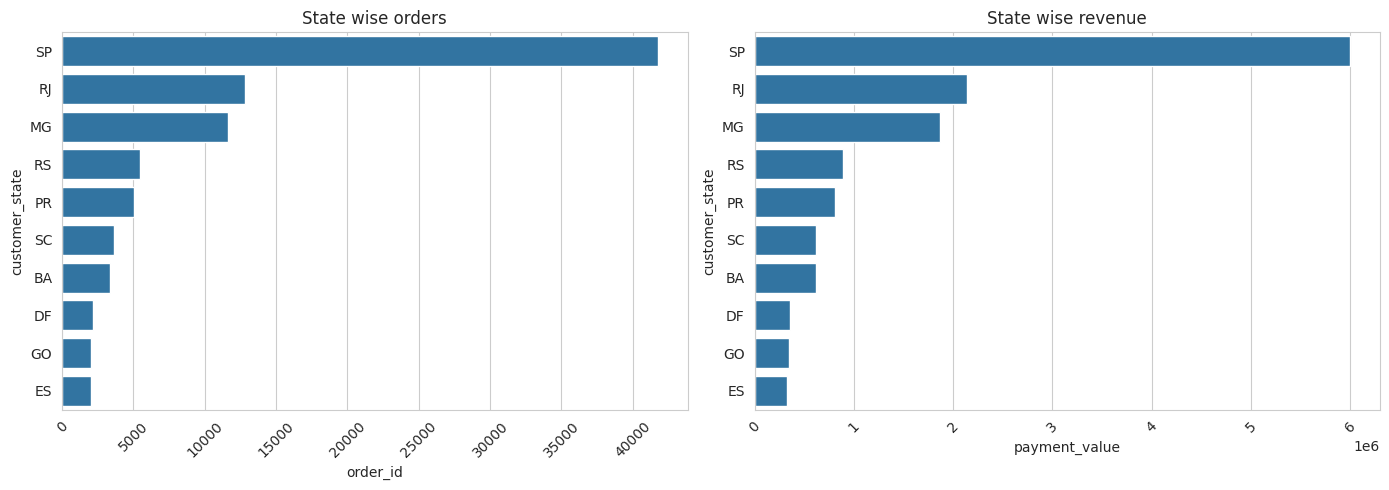

In [9]:
# merge orders + customers + payments
state_orders = pd.merge(orders, customers, on='customer_id')
state_revenue = pd.merge(state_orders, payments, on='order_id')

#groupby state
state_wise = state_revenue.groupby('customer_state').agg({'order_id' : 'nunique' , 'payment_value': 'sum'})
state_wise = state_wise.reset_index().sort_values('payment_value', ascending=False)

sp_revenue = state_wise[state_wise['customer_state'] == 'SP']['payment_value'].values[0]
total_revenue = state_wise['payment_value'].sum()
print(f'SP revenue share: {sp_revenue/total_revenue*100:.1f}%')

top3_revenue = state_wise.head(3)['payment_value'].sum()
print(f'Top 3 states revenue share: {top3_revenue/total_revenue*100:.1f}%')

# Q2 visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=state_wise.head(10), x="order_id", y="customer_state", ax=axes[0])
axes[0].set_title('State wise orders')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=state_wise.head(10), x="payment_value", y="customer_state", ax=axes[1])
axes[1].set_title('State wise revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Key Insights — State Performance
- Sao Paulo (SP) dominates with 41,745 orders and 5.99M BRL revenue — 3x more than second place
- Top 3 states (SP, RJ, MG) account for ~62% of total revenue
- SP, RJ and MG are Brazil's most economically active states and major urban centers
- Smaller states like RR, AP, AC have very low activity — potential untapped markets

### Q3. What is the average delivery time and are there delays?

We analyse delivery performance by calculating actual delivery time
and comparing it against estimated delivery dates.

In [7]:
# calculating delievery time (in days)
orders['delievery_time'] = orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
orders['delievery_time'] = orders['delievery_time'].dt.days

# calculating delays (in days). Positive value means late and negative values means early
orders['delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

# key metrics
avg_delievery = orders['delievery_time'].mean()
avg_delay = orders['delay'].mean()
late_orders = (orders['delay'] > 0).sum()
total_delievered = orders['delay'].notna().sum()

print(f'Average delievery time: {avg_delievery:.1f} days')
print(f'Average delay: {avg_delay:.1f} days')
print(f'Late orders: {late_orders} ({late_orders/total_delievered*100:.1f}%)')

Average delievery time: 12.1 days
Average delay: -11.9 days
Late orders: 6535 (6.8%)


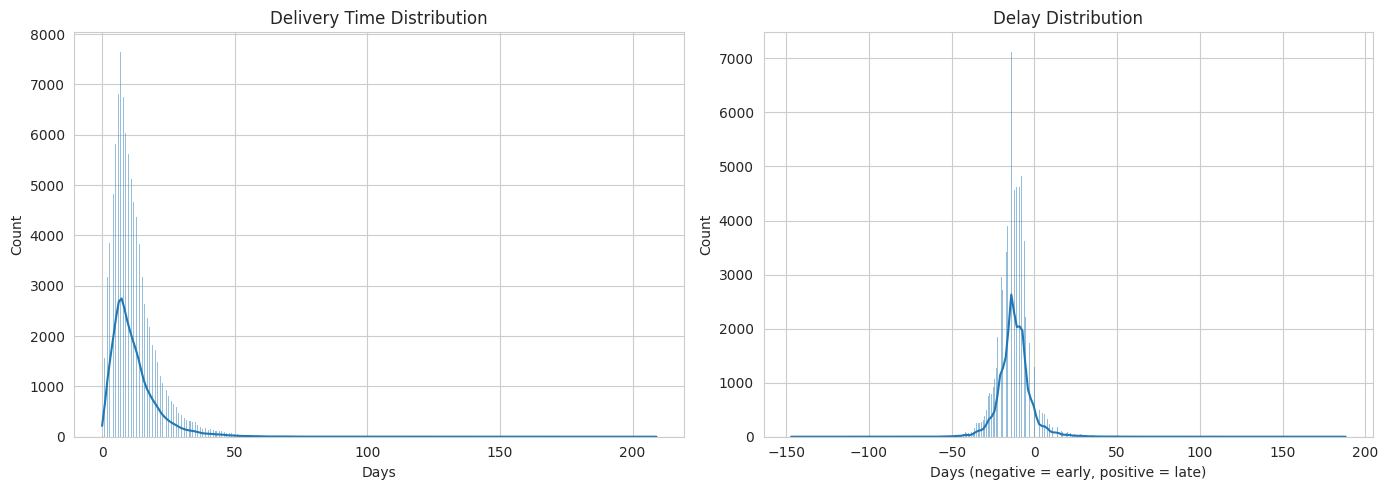

In [8]:
# Q3 visulaisation
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(data=orders, x='delievery_time', kde=True, ax=axes[0])
axes[0].set_title('Delivery Time Distribution')
axes[0].set_xlabel('Days')

sns.histplot(data=orders, x='delay', kde=True, ax=axes[1])
axes[1].set_title('Delay Distribution')
axes[1].set_xlabel('Days (negative = early, positive = late)')

plt.tight_layout()
plt.show()

### Key Insights — Delivery Performance
- Average delivery time is 12 days from order placement to customer receipt
- On average orders are delivered approximately 12 days BEFORE the estimated date — Olist sets very conservative estimates
- 6,535 orders (6.8%) were genuinely late — delivered after estimated date
- Delivery time distribution is right skewed — most orders deliver in 5-20 days but some extreme outliers took 100-200 days
- The delay distribution is centered around -10 to -20 days confirming most customers receive orders earlier than expected

## 4. Key Findings Summary

After analysing 100,000+ orders from Olist's e-commerce platform,
here are the top business insights:

1. **Strong Growth** — Olist grew 20x in order volume between late 2016
   and late 2017, stabilising at 6,000-7,000 orders per month in 2018

2. **Geographic Concentration** — Sao Paulo alone accounts for ~37% of
   all orders and revenue. Top 3 states (SP, RJ, MG) drive ~62% of business

3. **Delivery Performance** — Average delivery time is 12 days.
   Olist consistently delivers before estimated dates but 6.8% of orders
   are still late

4. **Untapped Markets** — Several smaller states have very low order
   volumes despite being sizeable populations — growth opportunity

In [28]:
print('Analysis Complete!')
print(" ")
print(f'Total orders analysed: {orders.shape[0]:,}')
print(f'Period: Sep 2016 - Aug 2018')
print(f'States covered: {state_wise.shape[0]}')
print(f'Average delievery time: {avg_delievery:.1f} days')
print(f'Late order rate: {late_orders/total_delievered*100:.1f}%')

Analysis Complete!
 
Total orders analysed: 99,441
Period: Sep 2016 - Aug 2018
States covered: 27
Average delievery time: 12.1 days
Late order rate: 6.8%
